# Checking FYs for JEFF-4.0

In [1]:
import sandy

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("ticks")

In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("FY_JEFF4_somenuclides.csv", index_col=0)
dferr = pd.read_csv("DFY_JEFF4_somenuclides.csv", index_col=0)

In [5]:
nuclides = [380900, 551370, 601430, 601450, 601440,  601450,  601460,  601470,  601480,  601500]

In [6]:
fy = sandy.get_endf6_file("jeff_33", "nfpy", 922350)
d = sandy.Fy.from_endf6(fy).data.query("MT==459 & E==2.53e-2")
d_33 = d[d.ZAP.isin(nuclides)].assign(LIB="JEFF-3.3")

In [7]:
fy = sandy.get_endf6_file("jeff_311", "nfpy", 922350)
d = sandy.Fy.from_endf6(fy).data.query("MT==459 & E==2.53e-2")
d_311 = d[d.ZAP.isin(nuclides)].assign(LIB="JEFF-3.1.1")

In [8]:
data = pd.concat([
    d_311,
    d_33,
], ignore_index=True)

In [9]:
vals = data.query("ZAM==922350").pivot_table(index="LIB", columns="ZAP", values="FY")
vals.columns = pd.Index(map(sandy.zam.zam2nuclide, vals.columns), name="ZAP")
vals = pd.concat([df, vals])
vals

,Sr90,Cs137,Nd143,Nd144,Nd145,Nd146,Nd147,Nd148,Nd150
C1,0.058063,0.062481,0.059420,0.054862,0.040262,0.029925,0.022534,0.016781,0.006596
C2,0.058076,0.062496,0.059434,0.054875,0.040272,0.029932,0.022540,0.016785,0.006598
S1,0.058572,0.061308,0.060302,0.055722,0.039164,0.029986,0.022025,0.016738,0.006543
S2,0.058479,0.063435,0.060491,0.055845,0.041049,0.029843,0.021911,0.016644,0.006513
JEFF-3.1.1,0.057290,0.062208,0.059541,0.054745,0.039439,0.029866,0.022320,0.016808,0.006507
JEFF-3.3,0.056759,0.060897,0.059522,0.054781,0.039560,0.029969,0.022465,0.016927,0.006538


In [10]:
err = data.query("ZAM==922350").pivot_table(index="LIB", columns="ZAP", values="DFY")
err.columns = pd.Index(map(sandy.zam.zam2nuclide, err.columns), name="ZAP")
err = pd.concat([dferr, err])
err

,Sr90,Cs137,Nd143,Nd144,Nd145,Nd146,Nd147,Nd148,Nd150
C1,0.001486,0.001699,0.001382,0.001276,0.000977,0.000791,0.000625,0.000499,0.000224
C2,0.001486,0.001700,0.001383,0.001276,0.000977,0.000791,0.000626,0.000499,0.000224
S1,0.000593,0.000623,0.000388,0.000370,0.000267,0.000248,0.000155,0.000149,0.000089
S2,0.000592,0.000693,0.000497,0.000477,0.000418,0.000387,0.000174,0.000206,0.000128
JEFF-3.1.1,0.001319,0.000694,0.000834,0.000547,0.000434,0.000299,0.000402,0.000118,0.000065
JEFF-3.3,0.001307,0.000633,0.000714,0.000492,0.000396,0.000300,0.000382,0.000118,0.000065


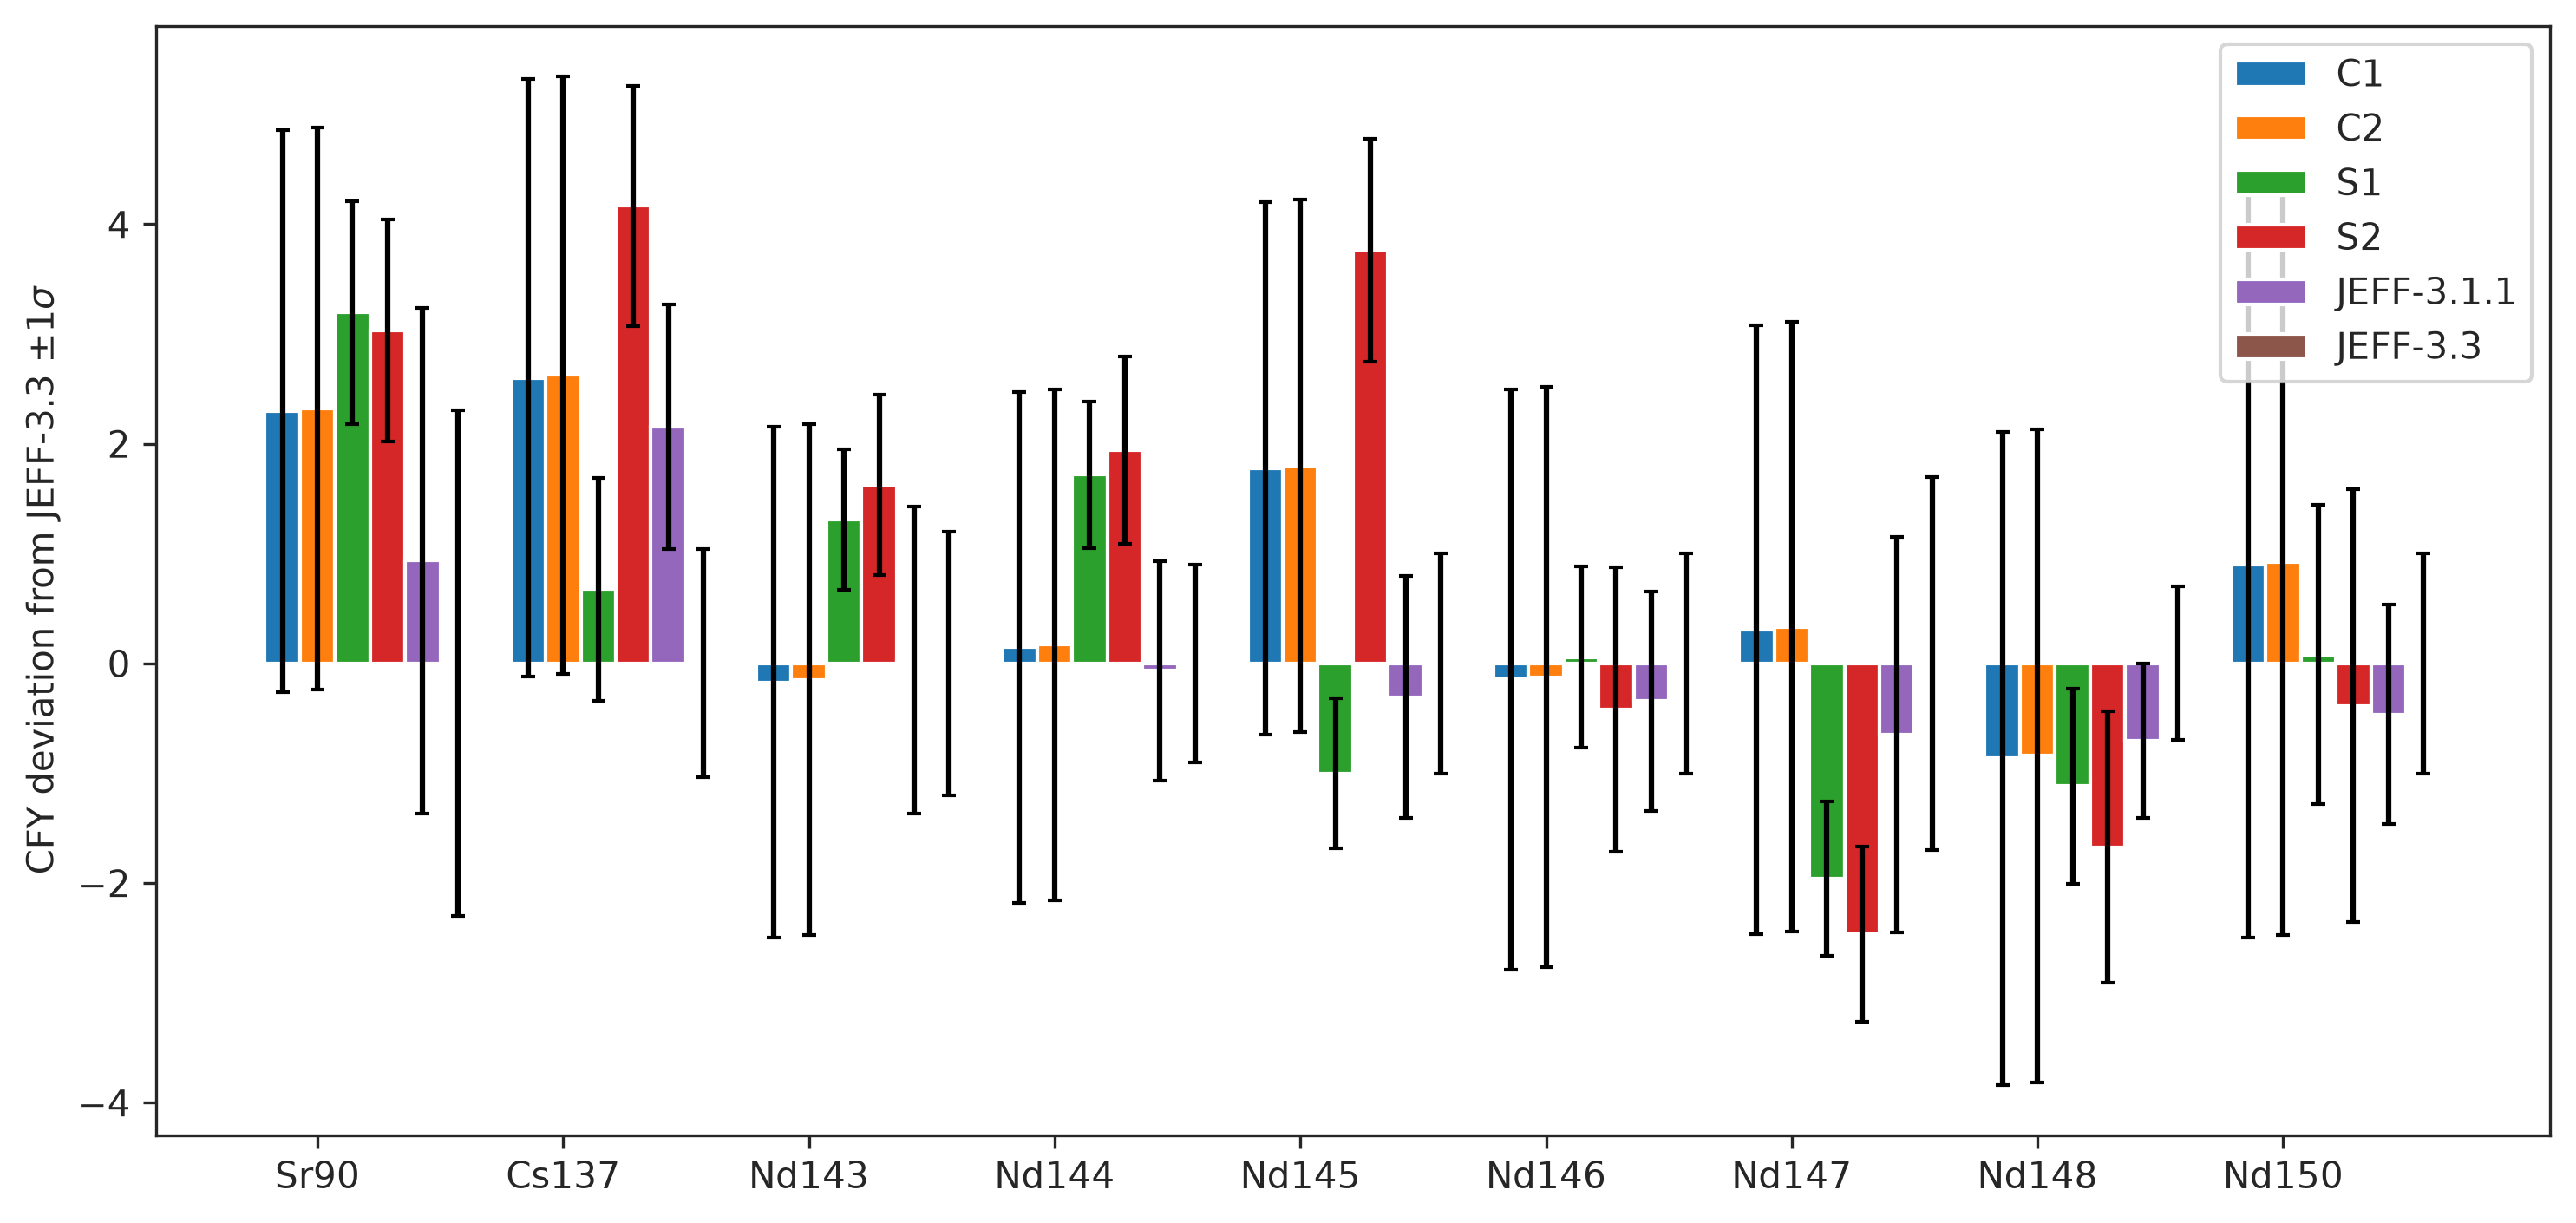

In [11]:
%%capture --no-display
fig, ax = plt.subplots(figsize=(10, 4.8), dpi=300)

vals2 = (vals/vals.iloc[-1] - 1)*100 
err2 = err/vals.iloc[-1]*100
err2 = err/vals*100
step = 1 / (vals2.T.columns.size + 1)
for i, LIB in enumerate(vals2.T.columns):
    x = np.arange(vals2.T[LIB].shape[0])
    ax.bar(data=vals2.T[LIB].reset_index(), x=x+i*step, height=LIB, yerr=err2.T[LIB], capsize=2, width=step)
ax.legend(labels=vals2.T.columns)
ticks = ax.get_xticks()
ax.set_xticklabels(vals2.columns.values)
ax.set_xticks(np.arange(len(vals2.columns)) + step)
ax.set(
    ylabel="CFY deviation from JEFF-3.3 $\\pm 1\\sigma$",
)
fig.tight_layout()

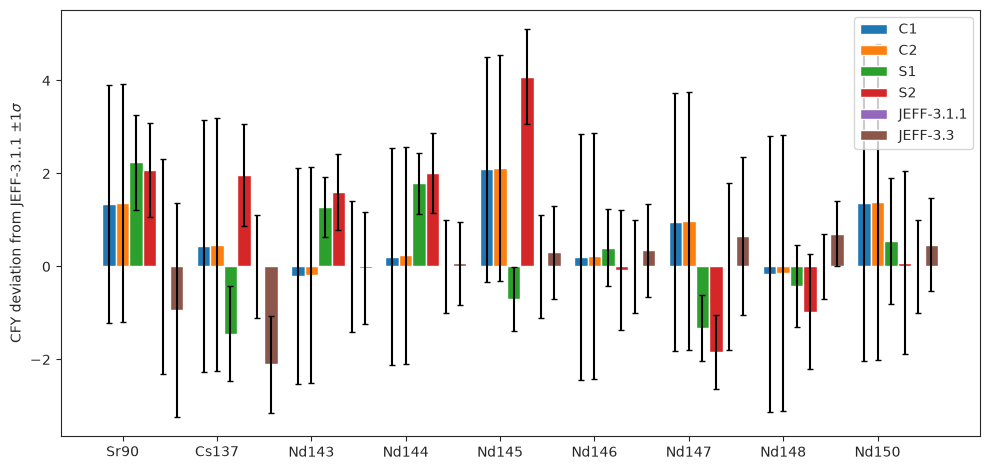

In [12]:
%%capture --no-display
fig, ax = plt.subplots(figsize=(10, 4.8), dpi=100)

vals2 = (vals/vals.iloc[-2] - 1)*100 
err2 = err/vals*100
step = 1 / (vals2.T.columns.size + 1)
for i, LIB in enumerate(vals2.T.columns):
    x = np.arange(vals2.T[LIB].shape[0])
    ax.bar(data=vals2.T[LIB].reset_index(), x=x+i*step, height=LIB, yerr=err2.T[LIB], capsize=2, width=step)
ax.legend(labels=vals2.T.columns)
ticks = ax.get_xticks()
ax.set_xticklabels(vals2.columns.values)
ax.set_xticks(np.arange(len(vals2.columns)) + step)
ax.set(
    ylabel="CFY deviation from JEFF-3.1.1 $\\pm 1\\sigma$",
)
fig.tight_layout();

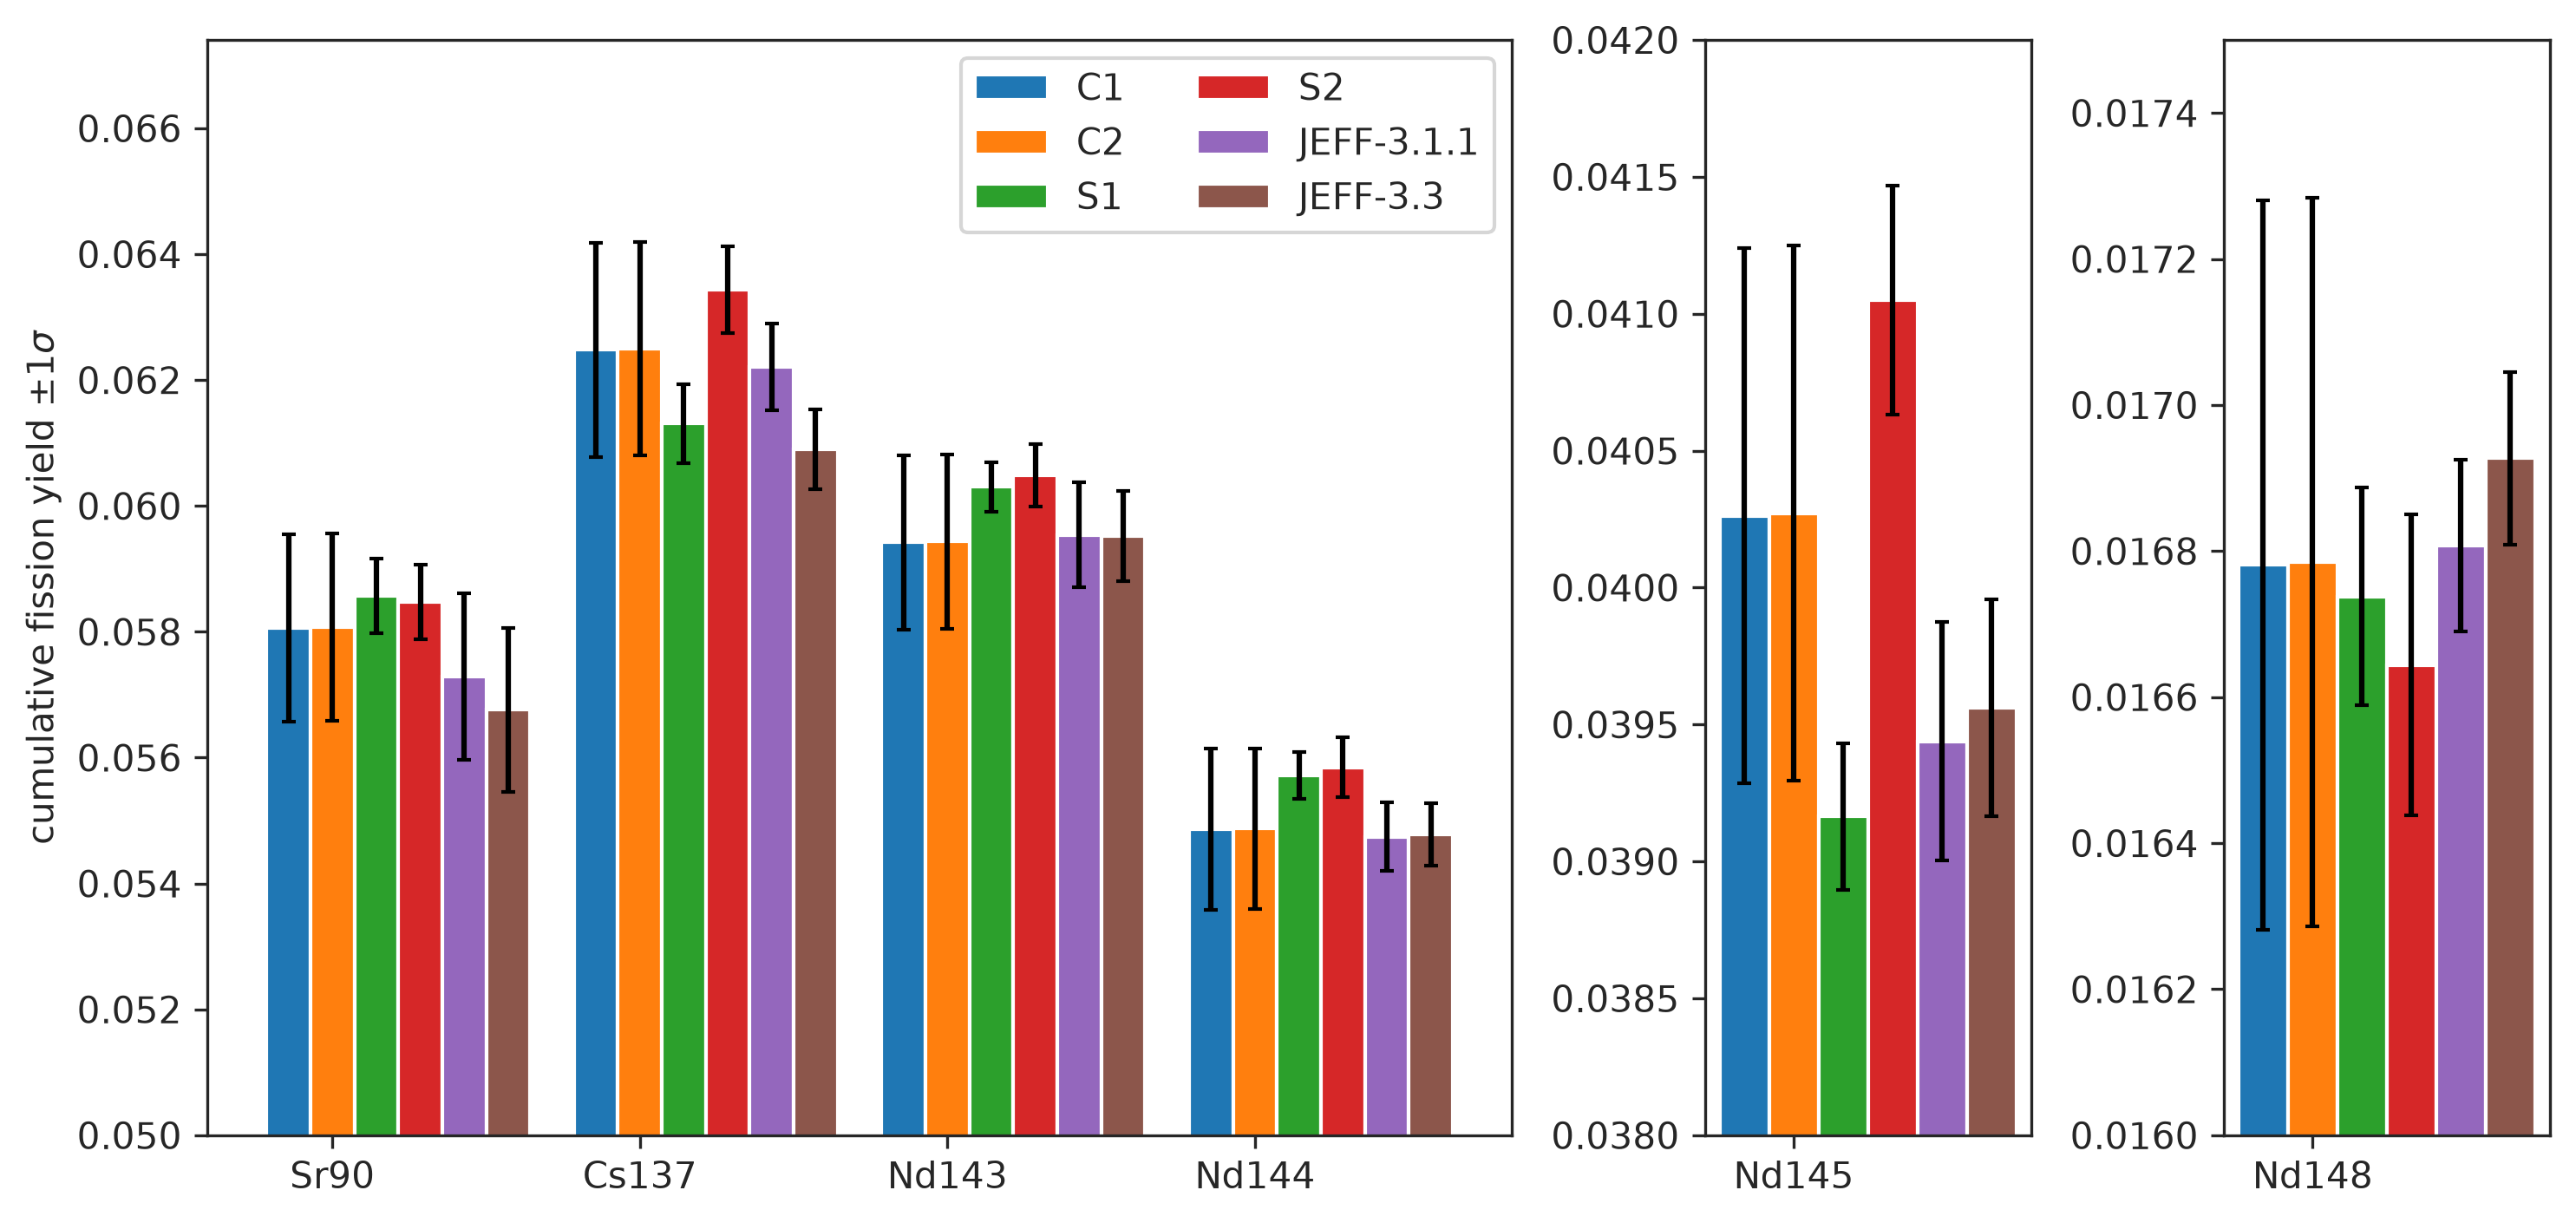

In [13]:
%%capture --no-display
fig, axs = plt.subplots(1, 3, figsize=(10, 4.8), dpi=300, gridspec_kw={'width_ratios': [4, 1, 1]})

ax = axs[0]
vals2 = vals.iloc[:, :4]
err2 = err.iloc[:, :4]
step = 1 / (vals2.T.columns.size + 1)
for i, LIB in enumerate(vals2.T.columns):
    x = np.arange(vals2.T[LIB].shape[0])
    ax.bar(data=vals2.T[LIB].reset_index(), x=x+i*step, height=LIB, yerr=err2.T[LIB], capsize=2, width=step)
ax.legend(labels=vals2.T.columns, ncol=2)
ticks = ax.get_xticks()
ax.set_xticklabels(vals2.columns.values)
ax.set_xticks(np.arange(len(vals2.columns)) + step)
ax.set(
    ylabel="cumulative fission yield $\\pm 1\\sigma$",
    ylim=(.05, None),
)

ax = axs[1]
vals2 = vals.iloc[:, 4:5]
err2 = err.iloc[:, 4:5]
step = 1 / (vals2.T.columns.size + 1)
for i, LIB in enumerate(vals2.T.columns):
    x = np.arange(vals2.T[LIB].shape[0])
    ax.bar(data=vals2.T[LIB].reset_index(), x=x+i*step, height=LIB, yerr=err2.T[LIB], capsize=2, width=step)
ax.legend(labels=vals2.T.columns)
ticks = ax.get_xticks()
ax.set_xticklabels(vals2.columns.values)
ax.set_xticks(np.arange(len(vals2.columns)) + step)
ax.get_legend().remove()
ax.set(
    ylabel=None,
    ylim=(.038, 0.042),
)

ax = axs[2]
vals2 = vals.iloc[:, 7:8]
err2 = err.iloc[:, 7:8]
step = 1 / (vals2.T.columns.size + 1)
for i, LIB in enumerate(vals2.T.columns):
    x = np.arange(vals2.T[LIB].shape[0])
    ax.bar(data=vals2.T[LIB].reset_index(), x=x+i*step, height=LIB, yerr=err2.T[LIB], capsize=2, width=step)
ax.legend(labels=vals2.T.columns)
ticks = ax.get_xticks()
ax.set_xticklabels(vals2.columns.values)
ax.set_xticks(np.arange(len(vals2.columns)) + step)
ax.get_legend().remove()
ax.set(
    ylabel=None,
    ylim=(.016, 0.0175),
)

fig.tight_layout();